In [2]:
import h5py
import numpy as np
with h5py.File("../data/lotka_volterra_data.h5", "r") as f:
    # Access the full dataset
    trajectories = f["trajectories"][:]
    time_points = f["time"][:]


In [3]:
trajectories.shape

(1000, 100, 2)

## Visualise Trajectories from the First System

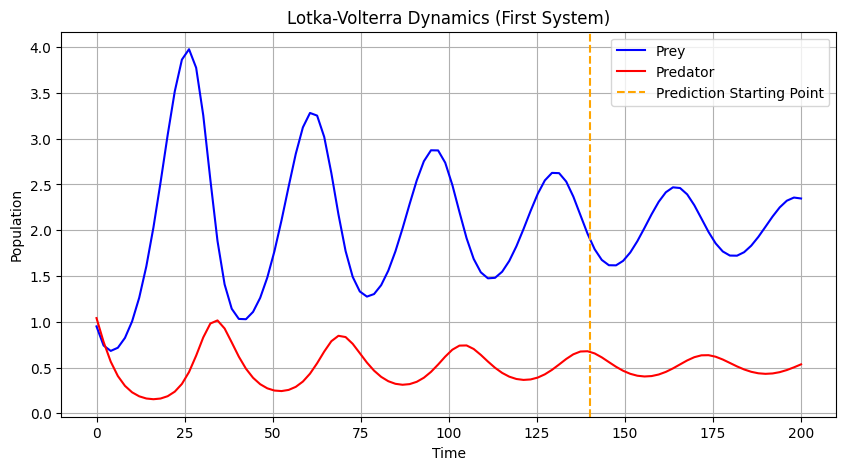

In [4]:
import matplotlib.pyplot as plt

# First system
prey1 = trajectories[0, :, 0]
predator1 = trajectories[0, :, 1]
times = time_points

plt.figure(figsize=(10, 5))
plt.plot(times, prey1, label="Prey", color="blue")
plt.plot(times, predator1, label="Predator", color="red")
plt.axvline(x=140, color="orange", linestyle="--", label="Prediction Starting Point")
plt.xlabel("Time")

plt.ylabel("Population")
plt.title("Lotka-Volterra Dynamics (First System)")
plt.legend()
plt.grid(True)
plt.show()


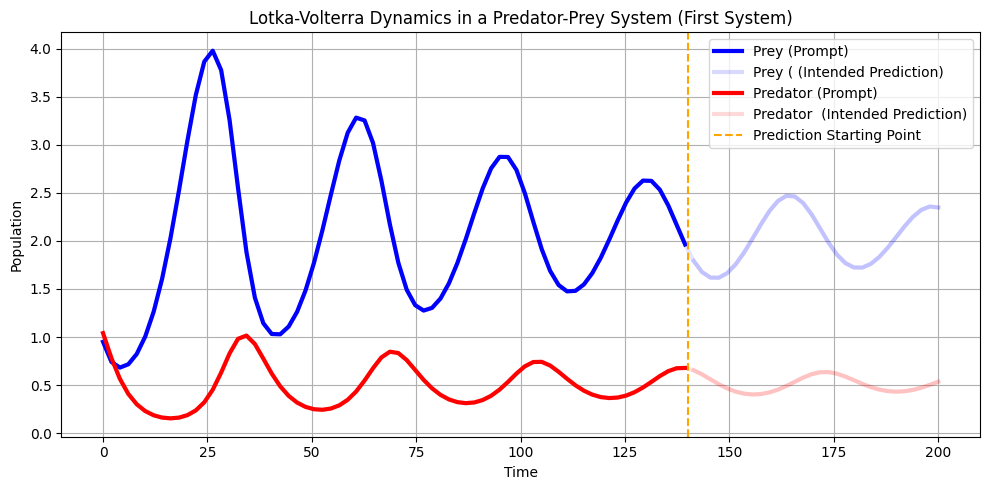

In [10]:
import matplotlib.pyplot as plt
import numpy as np


prediction_start = 140


actual_mask = times < prediction_start
forecast_mask = times >= prediction_start

plt.figure(figsize=(10, 5))
plt.plot(times, prey1, color="blue", alpha=0.1, linewidth=3)
plt.plot(times, predator1, color="red", alpha=0.1, linewidth=3)
plt.plot(times[actual_mask], prey1[actual_mask], label="Prey (Prompt)", color="blue", alpha=1.0, linewidth=3)
plt.plot(times[forecast_mask], prey1[forecast_mask], label = "Prey ( (Intended Prediction)", color="blue", alpha=0.15, linewidth=3)
plt.plot(times[actual_mask], predator1[actual_mask], label="Predator (Prompt)", color="red", alpha=1.0, linewidth=3)
plt.plot(times[forecast_mask], predator1[forecast_mask], label = "Predator  (Intended Prediction)", color="red", alpha=0.15, linewidth=3)

plt.axvline(x=prediction_start, color="orange", linestyle="--", label="Prediction Starting Point")

plt.xlabel("Time")
plt.ylabel("Population")

plt.title("Lotka-Volterra Dynamics in a Predator-Prey System (First System)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Check train-test distributions

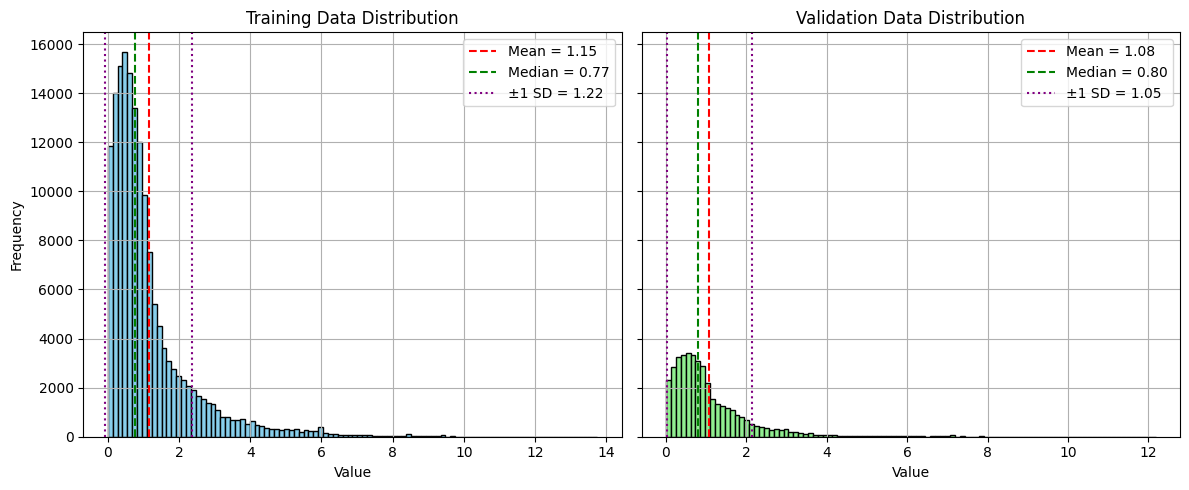

In [23]:
import sys

from src.preprocessor import load_and_preprocess
from src.lora_implemented import tokenise_data, prepare_data_loader, prepare_model, train


(train_set, train_idx), (validation_set, val_idx) = load_and_preprocess("../data/lotka_volterra_data.h5", alpha=1) # Load the data and split into train/val sets
val_samples = trajectories[val_idx]
train_samples = trajectories[train_idx]
flat_val = val_samples.reshape(-1)
flat_train = train_samples.reshape(-1)

train_mean = np.mean(flat_train)
train_median = np.median(flat_train)
train_std = np.std(flat_train)

val_mean = np.mean(flat_val)
val_median = np.median(flat_val)
val_std = np.std(flat_val)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)


axes[0].hist(flat_train, bins=100, color="skyblue", edgecolor="k")
axes[0].set_title("Training Data Distribution")
axes[0].axvline(train_mean, color="red", linestyle="--", label=f"Mean = {train_mean:.2f}")
axes[0].axvline(train_median, color="green", linestyle="--", label=f"Median = {train_median:.2f}")
axes[0].axvline(train_mean + train_std, color="purple", linestyle=":", label=f"±1 SD = {train_std:.2f}")
axes[0].axvline(train_mean - train_std, color="purple", linestyle=":")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Frequency")
axes[0].grid(True)
axes[0].legend()


axes[1].hist(flat_val, bins=100, color="lightgreen", edgecolor="k")
axes[1].set_title("Validation Data Distribution")
axes[1].axvline(val_mean, color="red", linestyle="--", label=f"Mean = {val_mean:.2f}")
axes[1].axvline(val_median, color="green", linestyle="--", label=f"Median = {val_median:.2f}")
axes[1].axvline(val_mean + val_std, color="purple", linestyle=":", label=f"±1 SD = {val_std:.2f}")
axes[1].axvline(val_mean - val_std, color="purple", linestyle=":")
axes[1].set_xlabel("Value")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [55]:
validation_set[2][1]

'0.902,0.258;1.026,0.243;1.172,0.237;1.333,0.241;1.495,0.255;1.637,0.281;1.736,0.319;1.768,0.368;1.719,0.423;1.596,0.477;1.422,0.517;1.236,0.537;1.070,0.531;0.943,0.505;0.858,0.467;0.813,0.424;0.804,0.383;0.825,0.346;0.873,0.315;0.946,0.292;1.041,0.277;1.154,0.270;1.276,0.272;1.397,0.282;1.504,0.302;1.579,0.331;1.608,0.366;1.583,0.406;1.506,0.445;1.390,0.475;'

In [93]:
# Mean of the validation prediction ground truth
from src.preprocessor import decode_prediction_to_array, tokenize
from transformers import AutoTokenizer
import numpy as np

model_name = "Qwen/Qwen2.5-0.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)

val_gt = validation_set[2]


# Flatten the list and calculate the mean
token_ids = tokenize(val_gt, tokenizer)

decoded_valgt = [decode_prediction_to_array(ids) for ids in token_ids]
flattened_decoded_valgt = np.concatenate(decoded_valgt, axis=0) 

# Mean
mean_val_gt = np.mean(flattened_decoded_valgt)

print("Mean of val_gt:", mean_val_gt)

Mean of val_gt: 1.1025175


## Determine a suitable value of alpha (Based on Training Set Only)

Min: 3.7355094e-05
Max: 13.740113
Median: 0.77274746
95th percentile: 3.6370091


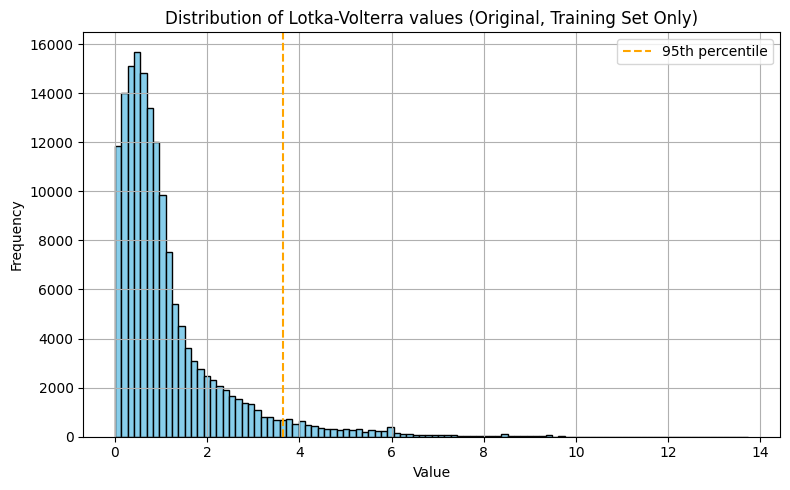

In [16]:
# Visualise original data distribution

from src.preprocessor import load_and_preprocess

(train_set, train_idx), (validation_set, val_idx) = load_and_preprocess("../data/lotka_volterra_data.h5", alpha=1) # Load the data and split into train/val sets
train_samples = trajectories[train_idx]
flat_train = train_samples.reshape(-1)

print("Min:", np.min(flat_train))
print("Max:", np.max(flat_train))
print("Median:", np.median(flat_train))
print("95th percentile:", np.percentile(flat_train, 95))


plt.figure(figsize=(8, 5))
plt.hist(flat_train, bins=100, color="skyblue", edgecolor="k")
plt.title("Distribution of Lotka-Volterra values (Original, Training Set Only)")
plt.axvline(np.percentile(flat_train, 95), color="orange", linestyle="--", label="95th percentile")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


After scaling by α = 0.36:
Min: 0.00010376415
Max: 38.16698
Median: 2.1465206
95th percentile: 10.102803
Percentage of values below 10: 94.88%


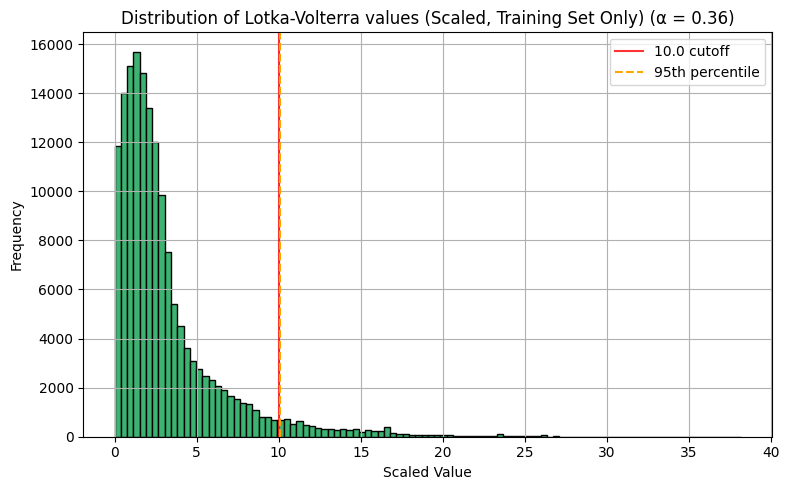

In [14]:
# Find a scaling factor to ensure 95% of the data ≤ 10

alpha = 0.36
scaled = flat_train / alpha

print(f"After scaling by α = {alpha:.2f}:")
print("Min:", np.min(scaled))
print("Max:", np.max(scaled))
print("Median:", np.median(scaled))
print("95th percentile:", np.percentile(scaled, 95))

percent_below_10 = np.mean(scaled < 10) * 100
print(f"Percentage of values below 10: {percent_below_10:.2f}%")


plt.figure(figsize=(8, 5))
plt.hist(scaled, bins=100, color="mediumseagreen", edgecolor="k")
plt.axvline(10, color="red", linestyle="-", label="10.0 cutoff", alpha=0.8)
plt.axvline(np.percentile(scaled, 95), color="orange", linestyle="--", label="95th percentile")
plt.title(f"Distribution of Lotka-Volterra values (Scaled, Training Set Only) (α = {alpha:.2f})")
plt.xlabel("Scaled Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Min: 3.7355094e-05
Max: 13.740113
Median: 0.77274746
95th percentile: 3.6370091
After scaling by α = 0.36:
Min: 0.00010376415
Max: 38.16698
Median: 2.1465206
95th percentile: 10.102803
Percentage of values below 10: 94.88%


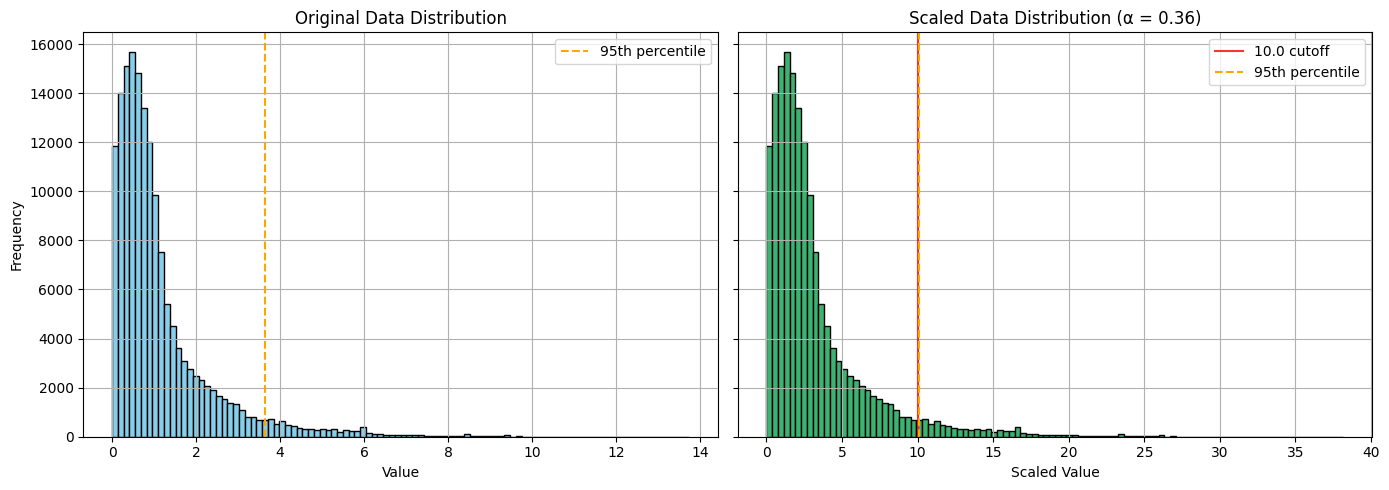

In [34]:
# Visualise original and scaled data distributions side by side

from src.preprocessor import load_and_preprocess

(train_set, train_idx), (validation_set, val_idx) = load_and_preprocess("../data/lotka_volterra_data.h5", alpha=1) # Load the data and split into train/val sets
train_samples = trajectories[train_idx]
flat_train = train_samples.reshape(-1)

# Calculate statistics
print("Min:", np.min(flat_train))
print("Max:", np.max(flat_train))
print("Median:", np.median(flat_train))
print("95th percentile:", np.percentile(flat_train, 95))

alpha = 0.36
scaled = flat_train / alpha

print(f"After scaling by α = {alpha:.2f}:")
print("Min:", np.min(scaled))
print("Max:", np.max(scaled))
print("Median:", np.median(scaled))
print("95th percentile:", np.percentile(scaled, 95))

percent_below_10 = np.mean(scaled < 10) * 100
print(f"Percentage of values below 10: {percent_below_10:.2f}%")

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Original data distribution
axes[0].hist(flat_train, bins=100, color="skyblue", edgecolor="k")
axes[0].set_title("Original Data Distribution")
axes[0].axvline(np.percentile(flat_train, 95), color="orange", linestyle="--", label="95th percentile")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Frequency")
axes[0].grid(True)
axes[0].legend()

# Scaled data distribution
axes[1].hist(scaled, bins=100, color="mediumseagreen", edgecolor="k")
axes[1].set_title(f"Scaled Data Distribution (α = {alpha:.2f})")
axes[1].axvline(10, color="red", linestyle="-", label="10.0 cutoff", alpha=0.8)
axes[1].axvline(np.percentile(scaled, 95), color="orange", linestyle="--", label="95th percentile")
axes[1].set_xlabel("Scaled Value")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

## Check Qwen2.5 Tokenization

In [31]:
# Tokenize the data
from src.preprocessor import tokenize
from transformers import AutoTokenizer

model_name = "Qwen/Qwen2.5-0.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)

text = ",1.0123456789;"

# encode to token IDs
tokenise_test = tokenize(text, tokenizer)

# print the token IDs
for t, tid in zip(text, tokenise_test):
    print(f"Token: {repr(t):<6} → ID: {tid}")

Token: ','    → ID: [11]
Token: '1'    → ID: [16]
Token: '.'    → ID: [13]
Token: '0'    → ID: [15]
Token: '1'    → ID: [16]
Token: '2'    → ID: [17]
Token: '3'    → ID: [18]
Token: '4'    → ID: [19]
Token: '5'    → ID: [20]
Token: '6'    → ID: [21]
Token: '7'    → ID: [22]
Token: '8'    → ID: [23]
Token: '9'    → ID: [24]
Token: ';'    → ID: [26]


## Check Correct Decoding and Rescaling Function

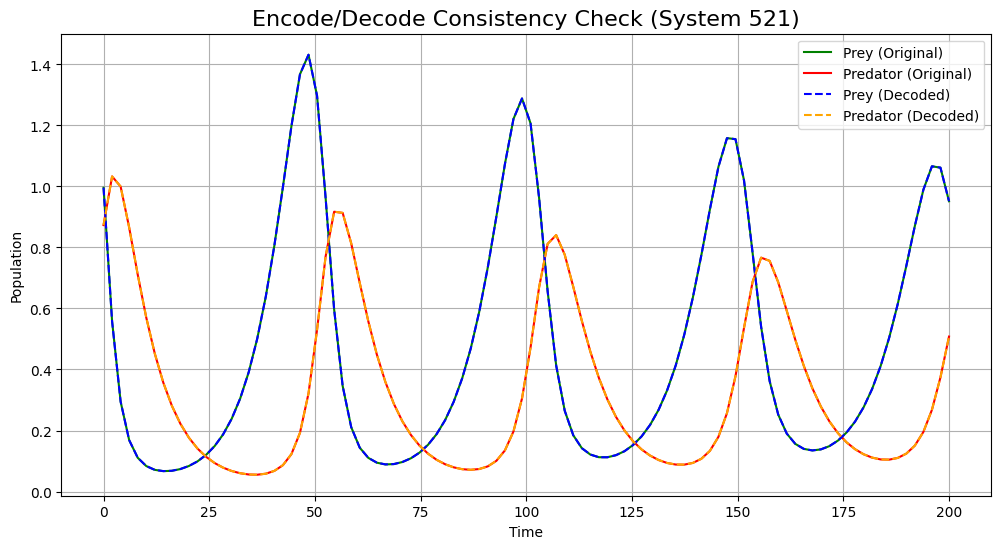

In [ ]:
# Plot to check correct decoding and rescaling

import matplotlib.pyplot as plt
import numpy as np
from src.preprocessor import decode_prediction_to_array, rescale, tokenize

# Load the preprocessed data
(train_set, train_idx), (val_set, val_idx) = load_and_preprocess(
    "../data/lotka_volterra_data.h5", alpha=0.36, precision=3
)

# Select a specific training system
i = 0
system_id = train_idx[i]  # Corresponding index in the original raw dataset

# Retrieve tokenized and formatted sequence from the preprocessed set
token_ids = tokenizer(train_set[0], return_tensors="pt")["input_ids"].tolist()[0]
formatted_str = train_set      # coresponding formatted string
decoded = decode_prediction_to_array(token_ids)
rescaled = rescale(decoded, alpha=0.36)

# Retrieve the original raw trajectory for comparison
traj_original = trajectories[system_id]
times = time_points

# Plot to visually compare original vs. decoded-rescaled trajectory
plt.figure(figsize=(12, 6))
plt.plot(times, traj_original[:, 0], label="Prey (Original)", color="green")
plt.plot(times, traj_original[:, 1], label="Predator (Original)", color="red")
plt.plot(times, rescaled[:, 0], '--', label="Prey (Decoded)", color="blue")
plt.plot(times, rescaled[:, 1], '--', label="Predator (Decoded)", color="orange")
plt.title(f"Encode/Decode Consistency Check (System {system_id})", fontsize=16)

plt.xlabel("Time")
plt.ylabel("Population")
plt.legend()
plt.grid(True)
plt.show()


## Share two example sequences, the preprocessed, and tokenized results (as sequences of integers, using the preprocessor you implemented, followed by mapping to Qwen2.5 tokens).

In [32]:
# Example 1: 

# Load the preprocessed data
(train_set, train_idx), (val_set, val_idx) = load_and_preprocess(
    "../data/lotka_volterra_data.h5", alpha=0.36, precision=3)

# Select a specific training system
idx1 = 10
processed_trajectory1 = train_set[idx1]
system_id1 = train_idx[idx1]  # Corresponding index in the original raw dataset

# Original trajectory
traj1 = trajectories[system_id1]

# Tokenize the trajectory
token_ids1 = tokenizer(processed_trajectory1, return_tensors="pt")["input_ids"].tolist()[0]

# demonstate
print(f"Original trajectory (system {system_id1}): {traj1[0:3, :]}")
print(f"Processed trajectory (system {system_id1}): {processed_trajectory1[0: 36]}")
print(f"Token IDs (system {system_id1}): {token_ids1[0: 36]}")

Original trajectory (system 811): [[0.92468953 1.0581826 ]
 [0.6988672  0.86723346]
 [0.60892767 0.6654375 ]]
Processed trajectory (system 811): 2.569,2.939;1.941,2.409;1.691,1.848;
Token IDs (system 811): [17, 13, 20, 21, 24, 11, 17, 13, 24, 18, 24, 26, 16, 13, 24, 19, 16, 11, 17, 13, 19, 15, 24, 26, 16, 13, 21, 24, 16, 11, 16, 13, 23, 19, 23, 26]


In [33]:
# Example 2: 

# Load the preprocessed data
(train_set, train_idx), (val_set, val_idx) = load_and_preprocess(
    "../data/lotka_volterra_data.h5", alpha=0.36, precision=3)

# Select a specific training system
idx2 = 20
processed_trajectory2 = train_set[idx2]
system_id2 = train_idx[idx2]  # Corresponding index in the original raw dataset

# Original trajectory
traj2 = trajectories[system_id2]

# Tokenize the trajectory
token_ids2 = tokenizer(processed_trajectory2, return_tensors="pt")["input_ids"].tolist()[0]

# demonstate
print(f"Original trajectory (system {system_id2}): {traj2[0:3, :]}")
print(f"Processed trajectory (system {system_id2}): {processed_trajectory2[0: 36]}")
print(f"Token IDs (system {system_id2}): {token_ids2[0: 36]}")

Original trajectory (system 549): [[0.8601669  1.1137589 ]
 [0.4966443  0.8798939 ]
 [0.35568136 0.6257832 ]]
Processed trajectory (system 549): 2.389,3.094;1.380,2.444;0.988,1.738;
Token IDs (system 549): [17, 13, 18, 23, 24, 11, 18, 13, 15, 24, 19, 26, 16, 13, 18, 23, 15, 11, 17, 13, 19, 19, 19, 26, 15, 13, 24, 23, 23, 11, 16, 13, 22, 18, 23, 26]
